# Project III: Traffic Accident Analysis in NYC (2025)

## Introduction

Dataset(s) to be used: 
**Motor Vehicle Collisions Data** from the [NYC Open Data Portal](https://data.cityofnewyork.us/Transportation/Motor-Vehicle-Collisions-2016-to-Present/ijzp-q8t2). This dataset includes information on traffic accidents in New York City from 2016 to the present, including details like the location of accidents, contributing factors, time, and the severity of the accidents.

- **NYPD Arrest Data** for the year 2025 from [NYC Open Data](https://data.cityofnewyork.us/Public-Safety/NYPD-Arrest-Data-Year-to-Date-/uip8-fykc/about_data). This dataset contains detailed information about arrests made in NYC, including arrest date, location, and crime type.

Analysis question: In NYC, do neighborhoods with higher poverty levels experience disproportionately higher arrest rates in 2025?

[Dataset 1] [LATITUDE] [LONGITUDE] [NTAName] [CRASH TIME] [CONTRIBUTING FACTOR VEHICLE] [NUMBER OF PERSONS INJURED] [NUMBER OF PEDESTRIANS INJURED]

[Dataset 2] [NTAName] [the_geom] [geometry]

Hypothesis: Higher poverty neighborhoods have higher arrest rates, especially for violent crimes. We will investigate whether there is a correlation between neighborhoods with higher accident rates and higher arrest rates, considering factors such as contributing factors to accidents and accident severity.


### Loading the Data

We will start by loading the traffic accident data and cleaning it to remove any rows with missing latitude or longitude information.

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [42]:
# Load the traffic accident data
crash_data = pd.read_csv('data/Motor_Vehicle.csv')
crash_data.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,12/06/2024,15:50,NaN,NaN,40.771347,-73.833390,"(40.771347, -73.83339)",LINDEN PLACE,I 678,NaN,...,Unspecified,NaN,NaN,NaN,4783211,Sedan,Sedan,NaN,NaN,NaN
1,12/06/2024,0:00,NaN,NaN,40.828804,-73.846860,"(40.828804, -73.84686)",CROSS BRONX EXPY,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4783514,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
2,12/06/2024,16:05,MANHATTAN,10019.0,40.766670,-73.980390,"(40.76667, -73.98039)",NaN,NaN,215 W 58 ST,...,Unspecified,Unspecified,Unspecified,NaN,4783565,Sedan,Sedan,Sedan,Sedan,NaN
3,12/06/2024,0:00,BRONX,10453.0,40.851100,-73.904680,"(40.8511, -73.90468)",GRAND CONC,E 179 ST,NaN,...,Unspecified,NaN,NaN,NaN,4783850,Sedan,Sedan,NaN,NaN,NaN
4,12/06/2024,9:00,NaN,NaN,40.608757,-74.038086,"(40.608757, -74.038086)",VERRAZANO BRIDGE UPPER,NaN,NaN,...,Unspecified,Unspecified,NaN,NaN,4784391,Sedan,Station Wagon/Sport Utility Vehicle,Convertible,NaN,NaN


In [43]:
# Data cleaning: Remove records with missing latitude and longitude
crash_data = crash_data.dropna(subset=['LATITUDE', 'LONGITUDE'])
crash_data.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,12/06/2024,15:50,NaN,NaN,40.771347,-73.833390,"(40.771347, -73.83339)",LINDEN PLACE,I 678,NaN,...,Unspecified,NaN,NaN,NaN,4783211,Sedan,Sedan,NaN,NaN,NaN
1,12/06/2024,0:00,NaN,NaN,40.828804,-73.846860,"(40.828804, -73.84686)",CROSS BRONX EXPY,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4783514,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
2,12/06/2024,16:05,MANHATTAN,10019.0,40.766670,-73.980390,"(40.76667, -73.98039)",NaN,NaN,215 W 58 ST,...,Unspecified,Unspecified,Unspecified,NaN,4783565,Sedan,Sedan,Sedan,Sedan,NaN
3,12/06/2024,0:00,BRONX,10453.0,40.851100,-73.904680,"(40.8511, -73.90468)",GRAND CONC,E 179 ST,NaN,...,Unspecified,NaN,NaN,NaN,4783850,Sedan,Sedan,NaN,NaN,NaN
4,12/06/2024,9:00,NaN,NaN,40.608757,-74.038086,"(40.608757, -74.038086)",VERRAZANO BRIDGE UPPER,NaN,NaN,...,Unspecified,Unspecified,NaN,NaN,4784391,Sedan,Station Wagon/Sport Utility Vehicle,Convertible,NaN,NaN


### GeoDataFrame for Neighborhood Tabulation Areas (NTA)

Next, we'll load the neighborhood tabulation area (NTA) shapefile, which provides the geographical boundaries for New York City's neighborhoods. We'll use this to map accident data to specific neighborhoods.

In [44]:
import geopandas as gpd
nta_data = pd.read_csv('data/Tabulation_Areas.csv')

nta_data['geometry'] = gpd.GeoSeries.from_wkt(nta_data['the_geom'])

# Create a GeoDataFrame for NTA
nta_gdf = gpd.GeoDataFrame(nta_data, geometry='geometry')
nta_gdf.set_crs("EPSG:4326", inplace=True)
nta_gdf.head()


,BoroCode,BoroName,CountyFIPS,NTA2020,NTAName,NTAAbbrev,NTAType,CDTA2020,CDTAName,Shape_Length,Shape_Area,the_geom,geometry
0,3,Brooklyn,47,BK0101,Greenpoint,Grnpt,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),"28,919.5611508","35,321,808.3909",MULTIPOLYGON (((-73.9321339742769 40.728159603...,"MULTIPOLYGON (((-73.93213 40.72816, -73.93238 ..."
1,3,Brooklyn,47,BK0102,Williamsburg,Wllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),"28,134.0826611","28,852,852.9133",MULTIPOLYGON (((-73.95814292411644 40.72440428...,"MULTIPOLYGON (((-73.95814 40.7244, -73.95772 4..."
2,3,Brooklyn,47,BK0103,South Williamsburg,SWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),"18,250.2800908","15,208,960.645",MULTIPOLYGON (((-73.95023693669857 40.70547324...,"MULTIPOLYGON (((-73.95024 40.70547, -73.94984 ..."
3,3,Brooklyn,47,BK0104,East Williamsburg,EWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),"43,184.8003755","52,267,406.735",MULTIPOLYGON (((-73.92405909659959 40.71411155...,"MULTIPOLYGON (((-73.92406 40.71411, -73.92404 ..."
4,3,Brooklyn,47,BK0201,Brooklyn Heights,BkHts,0,BK02,BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...,"14,312.1922849","9,982,022.78755",MULTIPOLYGON (((-73.9923636691119 40.689690123...,"MULTIPOLYGON (((-73.99236 40.68969, -73.99436 ..."


### GeoDataFrame for Traffic Accidents

Now we will convert the LATITUDE and LONGITUDE columns in the crash data into geographical points using shapely.geometry.Point. This will allow us to perform a spatial join later to count the number of accidents in each neighborhood.

In [45]:
print(nta_gdf.columns)  # Check column names in nta_gdf
print(accidents_count_by_nta.columns)  # Check column names in accidents_count_by_nta


Index(['BoroCode', 'BoroName', 'CountyFIPS', 'NTA2020', 'NTAName', 'NTAAbbrev',
       'NTAType', 'CDTA2020', 'CDTAName', 'Shape_Length', 'Shape_Area',
       'the_geom', 'geometry'],
      dtype='object')
Index(['NTAName', 'ACCIDENT_COUNT'], dtype='object')


### Spatial Join to Count Accidents by Neighborhood

Now, we perform a spatial join using overlay to find intersections between accident points and NTA polygons. This will give us the accident count for each NTA.

In [46]:
from shapely.geometry import Point

accidents_geometry = [Point(xy) for xy in zip(crash_data['LONGITUDE'], crash_data['LATITUDE'])]
accidents_gdf = gpd.GeoDataFrame(crash_data, geometry=accidents_geometry, crs="EPSG:4326")

# Use overlay to find intersections between accident points and NTA polygons
accidents_nta = gpd.overlay(accidents_gdf, nta_gdf, how='intersection')

# Step 8: Count accidents per NTA (Neighborhood Tabulation Area)
accidents_count_by_nta = accidents_nta.groupby('NTAName').size().reset_index(name='ACCIDENT_COUNT')

# Step 9: Merge the accident counts with the NTA GeoDataFrame
nta_gdf = nta_gdf.merge(accidents_count_by_nta, on='NTAName', how='left')

# Debugging: Check if 'ACCIDENT_COUNT' column is present in the merged GeoDataFrame
print(nta_gdf.columns)  # Display the columns of the merged GeoDataFrame
print(nta_gdf[['NTAName', 'ACCIDENT_COUNT']].head())

Index(['BoroCode', 'BoroName', 'CountyFIPS', 'NTA2020', 'NTAName', 'NTAAbbrev',
       'NTAType', 'CDTA2020', 'CDTAName', 'Shape_Length', 'Shape_Area',
       'the_geom', 'geometry', 'ACCIDENT_COUNT'],
      dtype='object')
              NTAName  ACCIDENT_COUNT
0          Greenpoint           404.0
1        Williamsburg           586.0
2  South Williamsburg           433.0
3   East Williamsburg           996.0
4    Brooklyn Heights           267.0


#### Visualizing Accident Counts by Neighborhood

We now visualize the number of accidents in each NTA neighborhood using a choropleth map, where darker shades represent neighborhoods with higher accident counts.

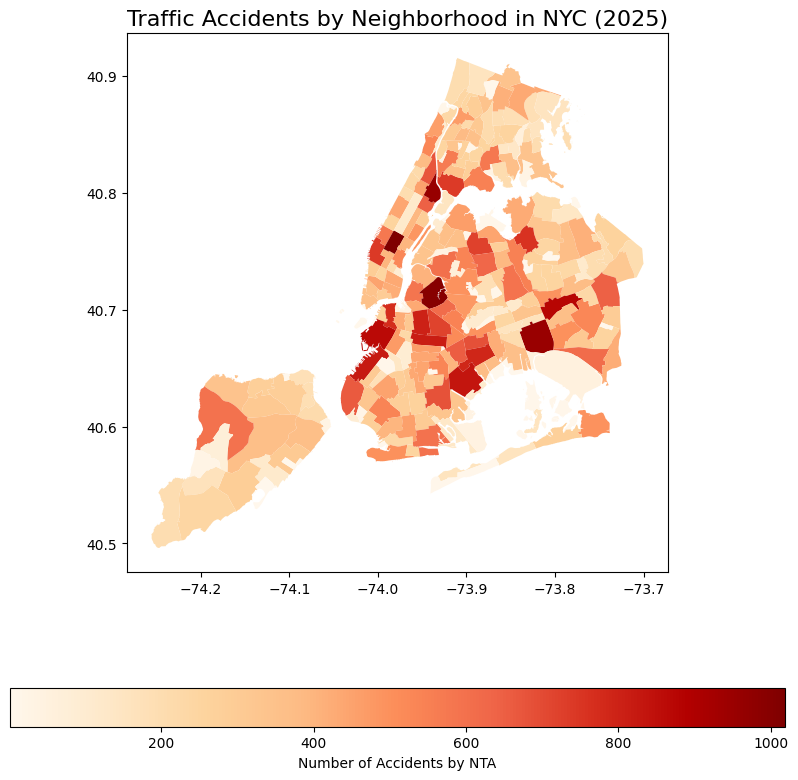

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

# Check if 'ACCIDENT_COUNT' is available before plotting
if 'ACCIDENT_COUNT' in nta_gdf.columns:
    nta_gdf.plot(column='ACCIDENT_COUNT', ax=ax, legend=True,
                 legend_kwds={'label': "Number of Accidents by NTA",
                              'orientation': "horizontal"},
                 cmap='OrRd')

    ax.set_title('Traffic Accidents by Neighborhood in NYC (2025)', fontsize=16)
    plt.show()
else:
    print("The 'ACCIDENT_COUNT' column is not found in the merged GeoDataFrame.")

The areas with darker red shades have a higher number of accidents, while lighter areas indicate neighborhoods with fewer accidents.

The darker red regions likely correspond to high-density neighborhoods or areas with more traffic.

Manhattan, especially the central and midtown areas, might have higher accident counts, which is common in densely populated urban centers with more vehicles and pedestrians.

Brooklyn and Queens might also show areas with significant accident concentrations, especially near major roads or industrial zones.

Staten Island and some parts of The Bronx might show relatively lighter shades, suggesting fewer accidents in certain less dense or suburban-like areas.

### Analyzing the Top Accident Hotspots

We will now identify the top 10 neighborhoods with the highest number of accidents. These hotspot neighborhoods will be the focus of further analysis.

In [54]:
# Get the top 10 NTA neighborhoods with the highest accident counts
top_hotspots = nta_gdf[['NTAName', 'ACCIDENT_COUNT']].sort_values(by='ACCIDENT_COUNT', ascending=False).head(10)

# Display the top hotspots
print(top_hotspots)

                                          NTAName  ACCIDENT_COUNT
130                          Midtown-Times Square          1019.0
3                               East Williamsburg           996.0
148                           East Harlem (North)           959.0
206                              South Ozone Park           953.0
215                                       Jamaica           879.0
20   Carroll Gardens-Cobble Hill-Gowanus-Red Hook           867.0
61                                       Canarsie           833.0
23                             Sunset Park (West)           823.0
27                          Crown Heights (North)           816.0
9                       Bedford-Stuyvesant (West)           801.0


In [56]:
print(accidents_nta.columns)
hotspot_ntas = top_hotspots['NTAName'].tolist()

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME',
       'OFF STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5',
       'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
       'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5',
       'BoroCode', 'BoroName', 'CountyFIPS', 'NTA2020', 'NTAName', 'NTAAbbrev',
       'NTAType', 'CDTA2020', 'CDTAName', 'Shape_Length', 'Shape_Area',
       'the_geom', 'geometry'],
      dtype='object')


### Contributing Factors to Accidents

We will now analyze the contributing factors to accidents in the top hotspots. We'll combine the contributing factors into a single column and count how frequently each factor occurs.

In [57]:
# Combine all contributing factors into a single column to count each factor
contributing_factors_columns = [
    'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2',
    'CONTRIBUTING FACTOR VEHICLE 3', 'CONTRIBUTING FACTOR VEHICLE 4',
    'CONTRIBUTING FACTOR VEHICLE 5'
]

# Filter accidents that happened in the top NTA neighborhoods
hotspot_accidents = accidents_nta[accidents_nta['NTAName'].isin(hotspot_ntas)]

# Combine contributing factors into a single column
all_contributing_factors = hotspot_accidents[contributing_factors_columns].stack().value_counts()

# Display the most common contributing factors
print(all_contributing_factors)




Unspecified                                              8596
Driver Inattention/Distraction                           2608
Failure to Yield Right-of-Way                             670
Following Too Closely                                     663
Other Vehicular                                           610
Passing or Lane Usage Improper                            494
Traffic Control Disregarded                               355
Unsafe Speed                                              351
Passing Too Closely                                       317
Backing Unsafely                                          277
Turning Improperly                                        269
Driver Inexperience                                       246
Unsafe Lane Changing                                      223
Pedestrian/Bicyclist/Other Pedestrian Error/Confusion     187
Alcohol Involvement                                       176
View Obstructed/Limited                                   105
Reaction

### Accident Severity Analysis

Now, let's analyze the severity of accidents in these hotspot areas. We'll calculate the total number of injuries and fatalities.

In [58]:
# Analyze accident severity in the hotspot neighborhoods
severity_columns = [
    'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
    'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED'
]

# Filter the hotspot accidents
hotspot_accidents_severity = hotspot_accidents[severity_columns]

# Calculate the total number of injuries and deaths in these areas
total_severity = hotspot_accidents_severity.sum()

# Display the total severity
print(total_severity)



NUMBER OF PERSONS INJURED        5254
NUMBER OF PERSONS KILLED           28
NUMBER OF PEDESTRIANS INJURED    1010
NUMBER OF PEDESTRIANS KILLED       15
NUMBER OF CYCLIST INJURED         699
NUMBER OF CYCLIST KILLED            3
NUMBER OF MOTORIST INJURED       3400
NUMBER OF MOTORIST KILLED          10
dtype: int64


In [ ]:
# Create a bar plot for contributing factors
fig = px.bar(all_contributing_factors, x=all_contributing_factors.index, y=all_contributing_factors.values,
             labels={'x': 'Contributing Factor', 'y': 'Frequency'},
             title='Most Common Contributing Factors in Hotspot Areas')

# Customize the appearance of the plot
fig.update_layout(
    xaxis_title='Contributing Factor',
    yaxis_title='Frequency',
    xaxis_tickangle=-45
)
# Save the plot as an image (PNG format)
fig.write_image("contributing_factors_bar.png")  # Save the bar plot as a PNG file

# Show the plot (optional in Jupyter, will still show the figure interactively)
fig.show()

The largest bar corresponds to the contributing factor "Driver Inattention/Distraction", which has the highest frequency. This suggests that driver distractions or inattention are the leading cause of accidents in the hotspot areas.

Driver Inattention and Failure to Yield are critical factors. These could be the focus of traffic safety interventions (e.g., public awareness campaigns, better signage, or enforcement of traffic laws related to these issues).

Cell phone use (even hands-free) and other lesser contributing factors like "Animal in Roadway" can still be considered for targeted traffic safety measures. For example, areas with high traffic and frequent distractions could benefit from more educational campaigns or technology such as advanced driver-assistance systems (ADAS).


### Time of Day Analysis

We'll now examine how accidents are distributed across day and night in the hotspot neighborhoods, based on the time of day.

In [61]:
# Convert 'CRASH_TIME' to datetime
hotspot_accidents['CRASH TIME'] = pd.to_datetime(hotspot_accidents['CRASH TIME'], errors='coerce')

# Extract the hour of the accident
hotspot_accidents['hour'] = hotspot_accidents['CRASH TIME'].dt.hour

# Check if there are any rows with missing or invalid 'CRASH_TIME'
print(hotspot_accidents[hotspot_accidents['CRASH TIME'].isna()])

# Create a 'time_of_day' column based on the hour (Day: 6AM-6PM, Night: 6PM-6AM)
hotspot_accidents['time_of_day'] = hotspot_accidents['hour'].apply(lambda x: 'Day' if 6 <= x < 18 else 'Night')

# Group by time of day and count the accidents
time_of_day_accidents = hotspot_accidents.groupby('time_of_day').size()

# Display the result
print(time_of_day_accidents)



Empty GeoDataFrame
Columns: [CRASH DATE, CRASH TIME, BOROUGH, ZIP CODE, LATITUDE, LONGITUDE, LOCATION, ON STREET NAME, CROSS STREET NAME, OFF STREET NAME, NUMBER OF PERSONS INJURED, NUMBER OF PERSONS KILLED, NUMBER OF PEDESTRIANS INJURED, NUMBER OF PEDESTRIANS KILLED, NUMBER OF CYCLIST INJURED, NUMBER OF CYCLIST KILLED, NUMBER OF MOTORIST INJURED, NUMBER OF MOTORIST KILLED, CONTRIBUTING FACTOR VEHICLE 1, CONTRIBUTING FACTOR VEHICLE 2, CONTRIBUTING FACTOR VEHICLE 3, CONTRIBUTING FACTOR VEHICLE 4, CONTRIBUTING FACTOR VEHICLE 5, COLLISION_ID, VEHICLE TYPE CODE 1, VEHICLE TYPE CODE 2, VEHICLE TYPE CODE 3, VEHICLE TYPE CODE 4, VEHICLE TYPE CODE 5, BoroCode, BoroName, CountyFIPS, NTA2020, NTAName, NTAAbbrev, NTAType, CDTA2020, CDTAName, Shape_Length, Shape_Area, the_geom, geometry, hour]
Index: []

[0 rows x 43 columns]
time_of_day
Day      5316
Night    3630
dtype: int64


/var/folders/wq/202j15cn72x_7mv_cy98qm300000gn/T/ipykernel_52016/4008757699.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/Users/yirange/computing/yg3102-del.github.io/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/yirange/computing/yg3102-del.github.io/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

In [ ]:
# Create the pie chart using Plotly
fig = px.pie(time_of_day_accidents, 
             names=time_of_day_accidents.index, 
             values=time_of_day_accidents.values,
             title='Accidents by Time of Day in Hotspot Areas')

fig_severity.write_image("accidents_by_time_of_day_pie.png")

# show the plot
fig.show()

Accidents occur more frequently during the daytime, with a higher proportion (close to 60%). This suggests that during the day, especially during peak traffic hours (such as rush hours), there are more accidents.

Nighttime accidents, while lower in proportion (around 40%), still represent a significant portion of accidents, likely linked to factors such as poor visibility, fatigue driving, or impaired driving.

Daytime accidents contribute more to overall severity in terms of both injuries and fatalities. This could be linked to higher traffic volumes and congestion during the day.

In [69]:
# Filter accidents that occurred during the daytime (time_of_day == 'Day')
daytime_accidents = hotspot_accidents[hotspot_accidents['time_of_day'] == 'Day']
nighttime_accidents = hotspot_accidents[hotspot_accidents['time_of_day'] == 'Night']

# Check severity of daytime accidents
daytime_severity = daytime_accidents[[
    'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED'
]].sum()

# Check severity of nighttime accidents
nighttime_severity = nighttime_accidents[[
    'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED'
]].sum()

# Display the total severity for both Day and Night
print("\nDaytime Accident Severity:")
print(daytime_severity)
print("\nNighttime Accident Severity:")
print(nighttime_severity)



Daytime Accident Severity:
NUMBER OF PERSONS INJURED        2997
NUMBER OF PERSONS KILLED           10
NUMBER OF PEDESTRIANS INJURED     643
NUMBER OF PEDESTRIANS KILLED        5
NUMBER OF CYCLIST INJURED         432
NUMBER OF CYCLIST KILLED            2
dtype: int64

Nighttime Accident Severity:
NUMBER OF PERSONS INJURED        2257
NUMBER OF PERSONS KILLED           18
NUMBER OF PEDESTRIANS INJURED     367
NUMBER OF PEDESTRIANS KILLED       10
NUMBER OF CYCLIST INJURED         267
NUMBER OF CYCLIST KILLED            1
dtype: int64


In [ ]:
# Combine the data into a long format (for better compatibility with Plotly)
severity_data = pd.DataFrame({
    'Accident Type': ['Persons Injured', 'Persons Killed', 'Pedestrians Injured', 'Pedestrians Killed', 'Cyclists Injured', 'Cyclists Killed'],
    'Daytime': daytime_severity.values,
    'Nighttime': nighttime_severity.values
})

severity_data_long = pd.melt(severity_data, id_vars=['Accident Type'], value_vars=['Daytime', 'Nighttime'],
                             var_name='Time of Day', value_name='Frequency')

# Create a stacked bar chart
fig_severity = px.bar(
    severity_data_long, 
    x='Accident Type', 
    y='Frequency', 
    color='Time of Day',
    title='Accident Severity Comparison: Daytime vs Nighttime',
    labels={'Accident Type': 'Type of Accident', 'Frequency': 'Severity (Total Count)', 'Time of Day': 'Time of Day'},
    color_discrete_map={'Daytime': "#DE8729", 'Nighttime': "#2B8FD6"},  # Softer colors
    barmode='stack'  # Set the bar mode to "stack" to make it stacked
)

# Update layout for better appearance
fig_severity.update_layout(
    xaxis_title='Type of Accident',
    yaxis_title='Total Severity (Count)',
    xaxis_tickangle=-45
)


# Show the plot
fig_severity.show()


It seems that daytime accidents contribute more to overall severity (in terms of both injuries and fatalities) than nighttime accidents. This might be due to higher traffic volume during the day, leading to more accidents, or other factors like driver inattention or congestion.

A significant portion of accidents occurs during the day (around 60%), but nighttime accidents are also prevalent, likely due to factors like impaired driving, fatigue, or poor visibility.

Findings: 

Initially, we expected that nighttime accidents might be more severe, given the potential risks associated with poor visibility and impaired driving. However, the analysis showed that daytime accidents actually contribute more significantly to overall severity. This finding may challenge our initial assumption that nighttime accidents are inherently more dangerous.

The correlation between high accident rates and high-density areas is not surprising, but it is worth noting that areas with high foot traffic and business activity are much more accident-prone. This reinforces the need for urban planning and infrastructure improvements in high-traffic areas.

Reflection: 

This analysis serves as a foundation for future investigations into urban safety and crime prevention, suggesting that both traffic accidents and social factors can be interwoven in understanding how urban environments can be improved for residents' safety. There is much more to explore, and this project has shown me how data can inform both immediate and long-term improvements in city planning and public safety.

This project allowed me to explore the intersection of traffic accidents, neighborhood density, and socioeconomic factors in New York City. The findings align with the general expectation that busy areas have higher accident rates, but the severity of daytime accidents was an interesting observation that adds depth to our understanding. The impact of driver behavior, particularly distractions and failure to yield, which suggests that education and law enforcement on safe driving could be key areas for improving traffic safety in hotspots.